In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
import json
import joblib


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)


In [3]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])


In [4]:
target = "load_actual"
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]


In [5]:
X_train = train[feature_names]
X_test  = test[feature_names]

y_train = train[target]
y_test  = test[target]


In [6]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    random_state=42
)

gbr.fit(X_train_scaled, y_train)
y_pred_gb = gbr.predict(X_test_scaled)


In [8]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

print("GB MAE :", mae_gb)
print("GB RMSE:", rmse_gb)
print("GB MAPE:", mape_gb)


GB MAE : 850.493066935964
GB RMSE: 1045.3045524273339
GB MAPE: 8.949735985561865


In [9]:
joblib.dump(gbr, "../saved_models/gbr_model.pkl")

['../saved_models/gbr_model.pkl']

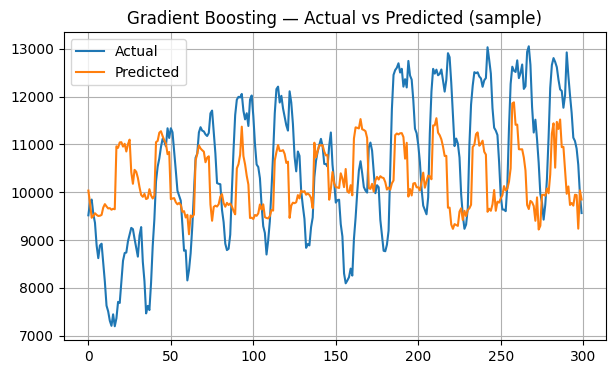

In [10]:
plt.figure(figsize=(7,4))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(y_pred_gb[:300], label="Predicted")
plt.title("Gradient Boosting — Actual vs Predicted (sample)")
plt.legend()
plt.grid(True)
plt.show()